In [23]:
from pathlib import Path
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [24]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print('Device:', DEVICE)

Device: mps


In [25]:
BATCH_SIZE = 64
SEQ_LEN = 100
STRIDE = SEQ_LEN          # non-overlapping training windows

EMBED_SIZE = 128
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.2             # applied between LSTM layers

LEARNING_RATE = 0.002
EPOCHS = 20

TEMPERATURE = 0.8

torch.manual_seed(42)

In [26]:
URL = (
    "https://raw.githubusercontent.com/"
    "karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
)

DATA_PATH = Path("tinyshakespeare.txt")

if not DATA_PATH.exists():
    print("Downloading dataset...")
    response = requests.get(URL, timeout=30)
    response.raise_for_status()
    DATA_PATH.write_text(response.text, encoding="utf-8")

text = DATA_PATH.read_text(encoding="utf-8")

print("Number of characters:", len(text))

Number of characters: 1115394


In [29]:
print(text[300:500])

 kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [30]:
chars = sorted(set(text))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

print('Vocab size :', vocab_size)
print('Chars: ', "".join(chars))

Vocab size : 65
Chars:  
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [31]:
def encode(s):
    return [stoi[c] for c in s]

def decode(indices):
    return "".join(itos[i] for i in indices)

print(encode('ROMEO'))
print(decode(encode('ROMEO')))

[30, 27, 25, 17, 27]
ROMEO


In [32]:
data = torch.tensor(encode(text), dtype=torch.long)

split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

print("Encoded data shape:", tuple(data.shape))
print("Train characters:", len(train_data))
print("Validation characters:", len(val_data))

Encoded data shape: (1115394,)
Train characters: 1003854
Validation characters: 111540


In [ ]:
class CharDataset(Dataset):

    def __init__(self, data, seq_len, stride):
        self.data = data
        self.seq_len = seq_len
        self.stride = stride
        self.n_samples = (len(data) - seq_len - 1) // stride + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        start = idx * self.stride
        x = self.data[start:start + self.seq_len]
        y = self.data[start + 1:start + self.seq_len + 1]
        return x, y

In [35]:
train_dataset = CharDataset(train_data, SEQ_LEN, STRIDE)
val_dataset = CharDataset(val_data, SEQ_LEN, STRIDE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 156
Validation batches: 17


In [36]:
x_batch, y_batch = next(iter(train_loader))

print("x:", tuple(x_batch.shape))
print("y:", tuple(y_batch.shape))
print("\ninput :", repr(decode(x_batch[0, :40].tolist())))
print("target:", repr(decode(y_batch[0, :40].tolist())))

x: (64, 100)
y: (64, 100)

input : ' the demigod Authority\nMake us pay down '
target: 'the demigod Authority\nMake us pay down f'


In [57]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.lstm = nn.LSTM(
            input_size = embed_size, 
            hidden_size = hidden_size, 
            num_layers = num_layers, 
            batch_first = True, 
            dropout = dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden = None):
        x = self.embedding(x)
        output, hidden = self.lstm(x, hidden)
        output = self.dropout(output)
        logits = self.fc(output)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device = device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device = device)

        return h0, c0

In [59]:
model = CharLSTM(
    vocab_size = vocab_size, 
    embed_size = EMBED_SIZE, 
    hidden_size = HIDDEN_SIZE, 
    num_layers = NUM_LAYERS, 
    dropout = DROPOUT, 
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())

print(model)

print(total_params)


CharLSTM(
  (embedding): Embedding(65, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=65, bias=True)
)
946625


In [60]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)


In [61]:
def train_one_epoch():
    model.train()
    total_loss = 0.0

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
        loss.backward()

        # gates keep gradients much healthier than a vanilla RNN,
        # but clipping is still cheap insurance
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [62]:
@torch.no_grad()
def evaluate():
    model.eval()
    total_loss = 0.0

    for x, y in val_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

        total_loss += loss.item()

    return total_loss / len(val_loader)


In [63]:
train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch()
    val_loss = evaluate()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

Epoch [01/20] | Train Loss: 2.2011 | Val Loss: 1.8755
Epoch [02/20] | Train Loss: 1.7053 | Val Loss: 1.7310
Epoch [03/20] | Train Loss: 1.5937 | Val Loss: 1.6736
Epoch [04/20] | Train Loss: 1.5363 | Val Loss: 1.6336
Epoch [05/20] | Train Loss: 1.5014 | Val Loss: 1.6145
Epoch [06/20] | Train Loss: 1.4763 | Val Loss: 1.6037
Epoch [07/20] | Train Loss: 1.4575 | Val Loss: 1.5908
Epoch [08/20] | Train Loss: 1.4434 | Val Loss: 1.5835
Epoch [09/20] | Train Loss: 1.4308 | Val Loss: 1.5821
Epoch [10/20] | Train Loss: 1.4199 | Val Loss: 1.5708
Epoch [11/20] | Train Loss: 1.4112 | Val Loss: 1.5744
Epoch [12/20] | Train Loss: 1.4033 | Val Loss: 1.5689
Epoch [13/20] | Train Loss: 1.3981 | Val Loss: 1.5663
Epoch [14/20] | Train Loss: 1.3920 | Val Loss: 1.5660
Epoch [15/20] | Train Loss: 1.3871 | Val Loss: 1.5606
Epoch [16/20] | Train Loss: 1.3823 | Val Loss: 1.5609
Epoch [17/20] | Train Loss: 1.3781 | Val Loss: 1.5552
Epoch [18/20] | Train Loss: 1.3745 | Val Loss: 1.5552
Epoch [19/20] | Train Loss: 

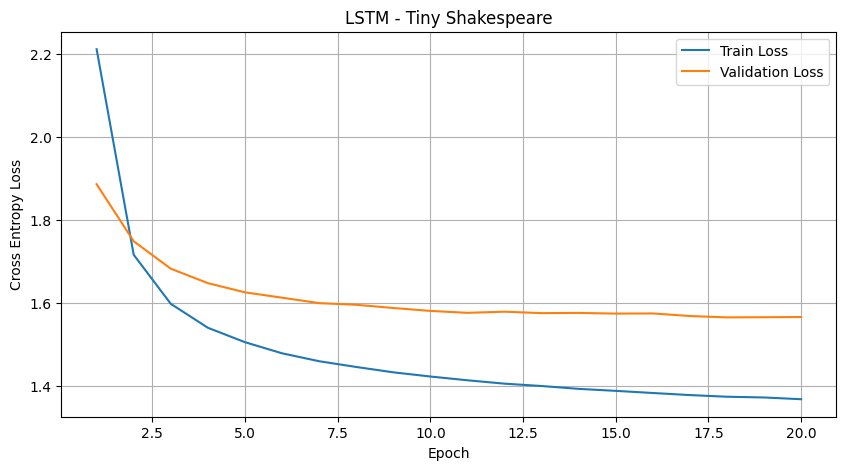

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("LSTM - Tiny Shakespeare")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
@torch.no_grad()
def generate_text(prompt, max_new_tokens=500, temperature=0.8):
    model.eval()

    input_ids = torch.tensor(
        encode(prompt), dtype=torch.long, device=DEVICE
    ).unsqueeze(0)   # [1, seq_len]

    hidden = model.init_hidden(batch_size=1, device=DEVICE)

    # warm the states up on the prompt, then feed one character at a time
    if input_ids.shape[1] > 1:
        _, hidden = model(input_ids[:, :-1], hidden)

    current = input_ids[:, -1:]
    generated = prompt

    for _ in range(max_new_tokens):
        logits, hidden = model(current, hidden)

        logits = logits[:, -1, :] / temperature
        probabilities = F.softmax(logits, dim=-1)

        next_char = torch.multinomial(probabilities, num_samples=1)

        generated += itos[next_char.item()]
        current = next_char

    return generated

In [66]:
print(generate_text("Hello", max_new_tokens=200, temperature=TEMPERATURE))

Hellow and men to the straught her!
Say belive his brother, but mew that with me that man will shame the grave;
But but happy again the men than nothing
As again but thou wouldstststly men.
Thethercily hat


In [67]:
checkpoint_path = "lstm_shakespeare.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "stoi": stoi,
        "itos": itos,
        "vocab_size": vocab_size,
        "embed_size": EMBED_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
    },
    checkpoint_path,
)

print("Model saved to:", checkpoint_path)

Model saved to: lstm_shakespeare.pt
